In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("CUDA version:", tf.sysconfig.get_build_info()['cuda_version'])
print("cuDNN version:", tf.sysconfig.get_build_info()['cudnn_version'])

TensorFlow version: 2.18.0
CUDA version: 12.5.1
cuDNN version: 9


In [ ]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [ ]:
#TODO replace the path with your path in drive
#This usually takes 15-20 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [ ]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [ ]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


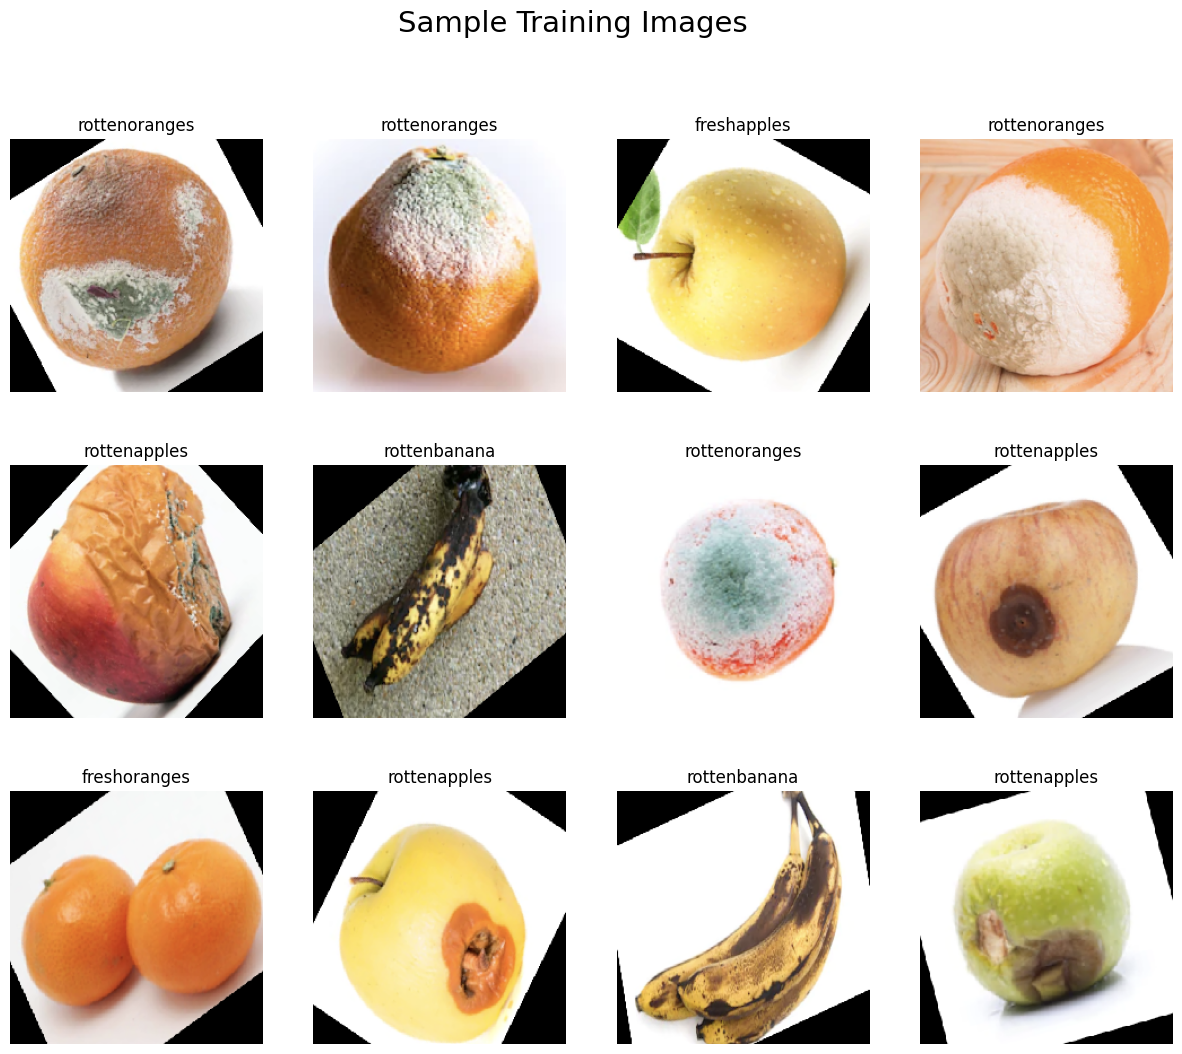

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [ ]:
from keras.applications.xception import Xception

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [ ]:
model = Xception(
    include_top=True,
    weights=None,
    input_tensor=Input(shape=(224, 224, 3)),
    input_shape=None,
    pooling=None,
    classes=6,
)


In [ ]:

from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("XCEPTION.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 20,873,774 (79.63 MB)

 Trainable params: 20,819,246 (79.42 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data= val_dataset,
    validation_steps = validationsteps
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6898 - loss: 0.9095
Epoch 1: val_loss improved from inf to 1.78434, saving model to XCEPTION.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 142s 397ms/step - accuracy: 0.6903 - loss: 0.9080 - val_accuracy: 0.2188 - val_loss: 1.7843 - learning_rate: 0.0010
Epoch 2/30
  2/187 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.8438 - loss: 0.5274

...

187/187 ━━━━━━━━━━━━━━━━━━━━ 39s 203ms/step - accuracy: 0.9772 - loss: 0.0675 - val_accuracy: 0.9688 - val_loss: 0.0517 - learning_rate: 6.6342e-04
Epoch 10/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9775 - loss: 0.0702
Epoch 10: val_loss did not improve from 0.05173
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.9787 - loss: 0.0662 - val_accuracy: 0.9688 - val_loss: 0.1708 - learning_rate: 6.3025e-04
Epoch 11/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9739 - loss: 0.0720
Epoch 11: val_loss improved from 0.05173 to 0.02425, saving model to XCEPTION.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 202ms/step - accuracy: 0.9739 - loss: 0.0720 - val_accuracy: 1.0000 - val_loss: 0.0243 - learning_rate: 5.9874e-04
Epoch 12/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9752 - loss: 0.0705
Epoch 12: val_loss did not improve from 0.02425
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9743 - loss: 0.0730 - val_accuracy: 0.7500 - val_loss: 1.3620 - learning_rate: 5.6880e-04
Epoch 13/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9812 - loss: 0.0584
Epoch 13: val_loss improved from 0.02425 to 0.01070, saving model to XCEPTION.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - accuracy: 0.9812 - loss: 0.0584 - val_accuracy: 1.0000 - val_loss: 0.0107 - learning_rate: 5.4036e-04
Epoch 14/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9923 - loss: 0.0264
Epoch 14: val_loss did not improve from 0.01070
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.9923 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 0.0119 - learning_rate: 5.1334e-04
Epoch 15/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9895 - loss: 0.0350
Epoch 15: val_loss did not improve from 0.01070
187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 204ms/step - accuracy: 0.9895 - loss: 0.0351 - val_accuracy: 0.9688 - val_loss: 0.0665 - learning_rate: 4.8767e-04
Epoch 16/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - accuracy: 0.9916 - loss: 0.0257
Epoch 16: val_loss improved from 0.01070 to 0.00054, saving model to XCEPTION.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.9925 - loss: 0.0243 - val_accuracy: 1.0000 - val_loss: 5.4267e-04 - learning_rate: 4.6329e-04
Epoch 17/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9925 - loss: 0.0231
Epoch 17: val_loss did not improve from 0.00054
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - accuracy: 0.9925 - loss: 0.0231 - val_accuracy: 1.0000 - val_loss: 0.0186 - learning_rate: 4.4013e-04
Epoch 18/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9950 - loss: 0.0230
Epoch 18: val_loss did not improve from 0.00054
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.9958 - loss: 0.0203 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 4.1812e-04
Epoch 19/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9971 - loss: 0.0100
Epoch 19: val_loss did not improve from 0.00054
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9971 - loss: 0.0101 - val_accuracy: 0.9688 - val_loss: 0.0565 - learning_rate: 3.9

187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 2.8520e-04 - learning_rate: 2.5034e-04
Epoch 29/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9979 - loss: 0.0067
Epoch 29: val_loss did not improve from 0.00029
187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 197ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9688 - val_loss: 0.1219 - learning_rate: 2.3783e-04
Epoch 30/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9987 - loss: 0.0053
Epoch 30: val_loss did not improve from 0.00029
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.9989 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 3.6945e-04 - learning_rate: 2.2594e-04


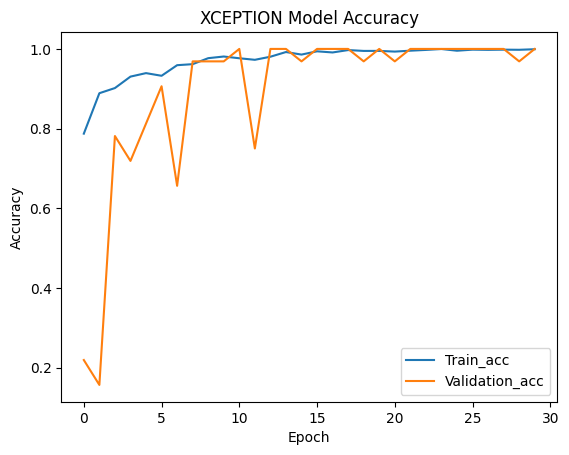

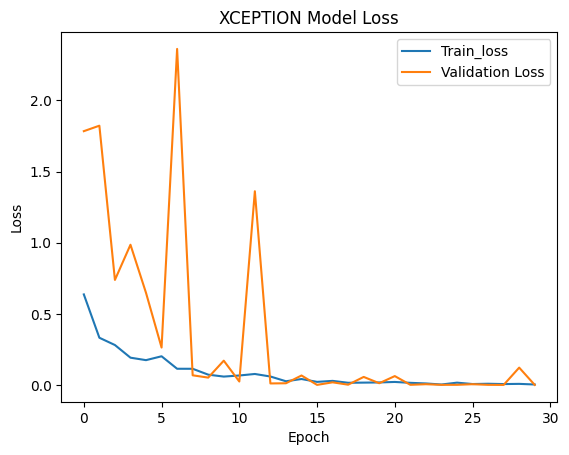

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('XCEPTION Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('XCEPTION Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.9997 - loss: 0.0018
accuracy test:  0.9985173940658569
loss test:  0.004388787318021059


In [ ]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step


In [ ]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


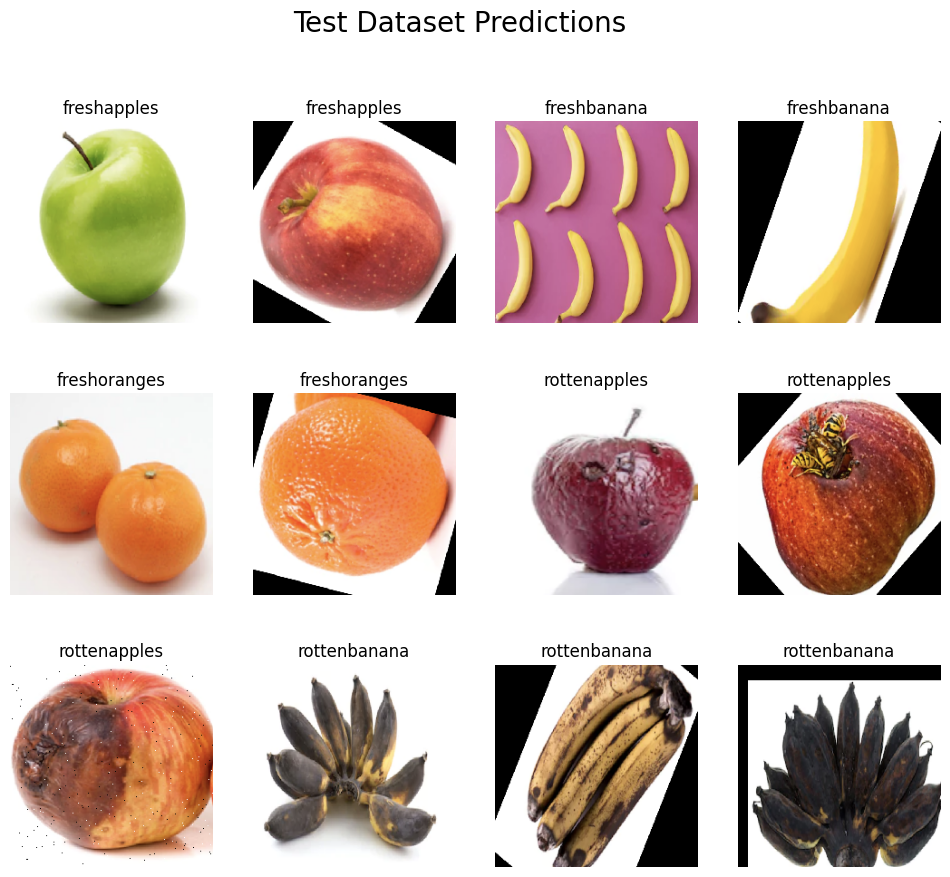

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [ ]:
# from keras.utils.vis_utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

# from tensorflow.keras.utils import plot_model # Importing plot_model from the correct module

# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 50.1 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [ ]:
test_steps_per_epoch = int(np.ceil(test_generator.samples / test_generator.batch_size))

In [ ]:

predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step


In [ ]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       1.00      1.00      1.00       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.99      1.00      1.00       388
 rottenapples       1.00      1.00      1.00       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      0.99      1.00       403

     accuracy                           1.00      2698
    macro avg       1.00      1.00      1.00      2698
 weighted avg       1.00      1.00      1.00      2698



In [ ]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


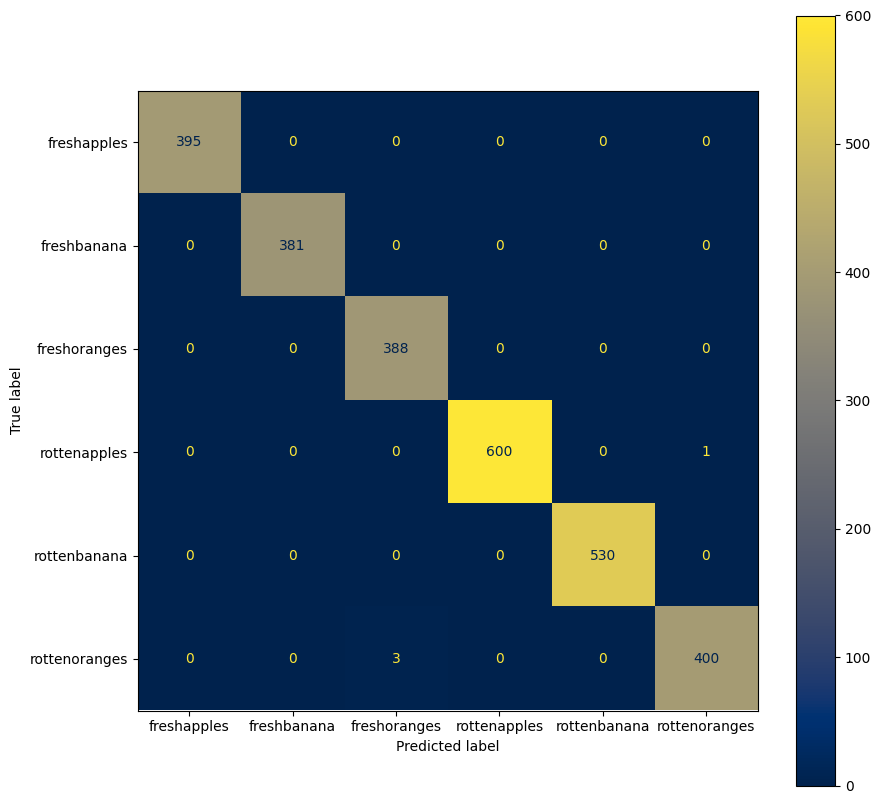

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')